## P67 - Push T

Ok, for paragraph 67 I need to figure out how to play and cached episodes, including actions so I can render them nicely with a "keyboard arrow" thing

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
import stable_worldmodel as swm
from tqdm import tqdm

print("cache:", swm.data.utils.get_cache_dir())

cache: /home/stephen/.stable_worldmodel


In [2]:
ds = swm.data.HDF5Dataset(name="pusht_expert_train",
                          keys_to_cache=["action", "proprio", "state"])
ep_starts = np.concatenate([[0], np.cumsum(ds.lengths)]).astype(np.int64)
# episode i occupies rows [ep_starts[i], ep_starts[i+1])

print("episodes available:", len(ds.lengths))
print("ep length stats:    min", ds.lengths.min(),
      " median", int(np.median(ds.lengths)),
      " max", ds.lengths.max())

episodes available: 18685
ep length stats:    min 49  median 123  max 246


In [3]:
N_EPISODES = 100
OUT_DIR    = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/jepa_2/hackin/push_t_episodes")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def to_hwc_uint8(t):                       # (1, 3, H, W) torch.uint8 -> (H, W, 3) np.uint8
    return t.squeeze(0).permute(1, 2, 0).cpu().numpy()

# rough size estimate so you know what you're committing to
total_frames = int(ds.lengths[:N_EPISODES].sum())
print(f"exporting {N_EPISODES} episodes, {total_frames} frames total")
print(f"~{total_frames * 224 * 224 * 3 / 1e9:.2f} GB raw, PNGs will be much smaller")

exporting 100 episodes, 10900 frames total
~1.64 GB raw, PNGs will be much smaller


In [4]:
len(ep_starts)

18686

In [5]:
ep_id=8

ep_len = int(ds.lengths[ep_id])
row0   = int(ep_starts[ep_id])

ep_dir     = OUT_DIR / f"ep_{ep_id:04d}"
frames_dir = ep_dir / "frames"
frames_dir.mkdir(parents=True, exist_ok=True)

actions  = np.empty((ep_len, 2), dtype=np.float32)
proprio  = np.empty((ep_len, 4), dtype=np.float32)
state    = np.empty((ep_len, 7), dtype=np.float32)
step_idx = np.empty((ep_len,),   dtype=np.int64)

In [6]:
t=50
sample = ds[row0 + t]
img    = to_hwc_uint8(sample["pixels"])
Image.fromarray(img).save(frames_dir / f"{t:04d}.png")

actions[t]  = sample["action"].squeeze(0).cpu().numpy()
proprio[t]  = sample["proprio"].squeeze(0).cpu().numpy()
state[t]    = sample["state"].squeeze(0).cpu().numpy()
step_idx[t] = int(sample["step_idx"].item())


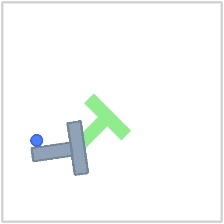

In [7]:
Image.fromarray(img)

In [8]:
from __future__ import annotations
import numpy as np
import scipy.ndimage as ndi
 
 
def _hex(h: str) -> np.ndarray:
    h = h.lstrip("#")
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=np.float32)
 
 
# Welch Labs palette
CHILL_BROWN = _hex("#948979")
YELLOW      = _hex("#ffd35a")
YELLOW_FADE = _hex("#7f6a2d")
BLUE        = _hex("#00AEEF")
BLACK       = np.zeros(3, dtype=np.float32)
 

In [9]:
DEFAULT_PALETTE: dict = {
    # ── source anchors (sampled by hand from the PushT renderer) ─────────
    "src_bg":            np.array([255, 255, 255], dtype=np.float32),
    "src_frame_border":  np.array([205, 205, 205], dtype=np.float32),
    "src_target_fill":   np.array([130, 236, 138], dtype=np.float32),  # green T
    "src_movable_fill":  np.array([130, 153, 172], dtype=np.float32),  # blue-gray T
    "src_effector_fill": np.array([ 70, 119, 246], dtype=np.float32),  # blue dot
    "src_target_outline":   np.array([170, 212, 161], dtype=np.float32),  # green T
    "src_movable_outline":  np.array([125, 136, 143], dtype=np.float32),  # blue-gray T
    "src_effector_outline": np.array([94, 115, 167], dtype=np.float32),  # blue dot
 
    # ── target colors ────────────────────────────────────────────────────
    "tgt_bg":               BLACK,
    "tgt_frame_border":     BLACK,
    "tgt_target_fill":      CHILL_BROWN,
    "tgt_target_outline":   CHILL_BROWN, # * 0.55,
    "tgt_movable_fill":     BLUE,
    "tgt_movable_outline":  BLUE * 0.75,
    "tgt_effector_fill":    YELLOW,
    "tgt_effector_outline": YELLOW,
 
    # ── fill-mask thresholds (loose color-ball radii) ────────────────────
    # Only used to seed the Voronoi label propagation; doesn't need to be tight.
    "r_target_fill":   45.0,
    "r_movable_fill":  22.0,
    "r_effector_fill": 55.0,
 
    # ── connected-component cleanup ──────────────────────────────────────
    # Drop fill-mask components smaller than this many pixels (kills stray AA
    # pixels that happen to fall inside a fill color ball).
    "min_component_size": 10,
}
 
 
# Per-shape (label_id, fill_src_key, outline_src_key, fill_tgt_key, outline_tgt_key)
_SHAPES = [
    (1, "src_target_fill",   "src_target_outline",   "tgt_target_fill",   "tgt_target_outline"),
    (2, "src_movable_fill",  "src_movable_outline",  "tgt_movable_fill",  "tgt_movable_outline"),
    (3, "src_effector_fill", "src_effector_outline", "tgt_effector_fill", "tgt_effector_outline"),
]
 
 
def _keep_largest_components(mask: np.ndarray, min_size: int) -> np.ndarray:
    """Drop connected components smaller than min_size pixels."""
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = ndi.sum_labels(mask, lab, range(1, n + 1))
    keep = np.zeros(n + 1, dtype=bool)
    keep[1:] = sizes >= min_size
    return keep[lab]
 
 
def _segment_shapes(img: np.ndarray, p: dict) -> np.ndarray:
    """Per-pixel shape label via threshold + cleanup + Voronoi propagation."""
    def ball(anchor, r):
        return np.linalg.norm(img - anchor, axis=-1) < r
 
    min_sz = int(p["min_component_size"])
    labels = np.zeros(img.shape[:2], dtype=np.int32)
    labels[_keep_largest_components(ball(p["src_target_fill"],   p["r_target_fill"]),   min_sz)] = 1
    labels[_keep_largest_components(ball(p["src_movable_fill"],  p["r_movable_fill"]),  min_sz)] = 2
    labels[_keep_largest_components(ball(p["src_effector_fill"], p["r_effector_fill"]), min_sz)] = 3
 
    if (labels == 0).all():
        # Pure-background frame; return zeros — output will be BLACK everywhere via bg anchor.
        return labels
 
    _, idx = ndi.distance_transform_edt(labels == 0, return_indices=True)
    return labels[idx[0], idx[1]]
 
 
def recolor_pusht(
    frame: np.ndarray,
    palette: dict | None = None,
    sigma: float = 22.0,
) -> np.ndarray:
    """Recolor one PushT frame.
 
    Args:
        frame:   (H, W, 3) uint8 RGB array.
        palette: dict matching DEFAULT_PALETTE structure (or None for defaults).
        sigma:   Gaussian σ in RGB units. 12 = very crisp, 22 = default, 35 = soft.
 
    Returns:
        (H, W, 3) uint8 RGB array.
    """
    p = palette if palette is not None else DEFAULT_PALETTE
    img = frame.astype(np.float32)
    H, W, _ = img.shape
 
    # 1. Spatial label per pixel
    lbl = _segment_shapes(img, p)
 
    # 2. Per-pixel fill/outline anchors based on shape label
    src_fill_pp    = np.empty_like(img)
    src_outline_pp = np.empty_like(img)
    tgt_fill_pp    = np.empty_like(img)
    tgt_outline_pp = np.empty_like(img)
    for lbl_val, sf_key, so_key, tf_key, to_key in _SHAPES:
        m = (lbl == lbl_val)
        if not m.any():
            continue
        src_fill_pp[m]    = p[sf_key]
        src_outline_pp[m] = p[so_key]
        tgt_fill_pp[m]    = p[tf_key]
        tgt_outline_pp[m] = p[to_key]
 
    # Fallback: if no shape was detected anywhere, point the shape anchors at bg
    # so they don't contribute spurious color via uninitialized memory.
    if (lbl == 0).any():
        src_fill_pp[lbl == 0]    = p["src_bg"]
        src_outline_pp[lbl == 0] = p["src_bg"]
        tgt_fill_pp[lbl == 0]    = p["tgt_bg"]
        tgt_outline_pp[lbl == 0] = p["tgt_bg"]
 
    # 3. Global bg + frame_border anchors broadcast to per-pixel shape
    bg_src    = np.broadcast_to(p["src_bg"],           img.shape)
    bg_tgt    = np.broadcast_to(p["tgt_bg"],           img.shape)
    frame_src = np.broadcast_to(p["src_frame_border"], img.shape)
    frame_tgt = np.broadcast_to(p["tgt_frame_border"], img.shape)
 
    src_pp = np.stack([src_fill_pp, src_outline_pp, bg_src, frame_src], axis=-2)  # (H, W, 4, 3)
    tgt_pp = np.stack([tgt_fill_pp, tgt_outline_pp, bg_tgt, frame_tgt], axis=-2)
 
    # 4. Gaussian soft blend over the 4 anchors
    d2 = ((img[..., None, :] - src_pp) ** 2).sum(-1)            # (H, W, 4)
    w  = np.exp(-d2 / (2.0 * sigma * sigma))
    w /= w.sum(-1, keepdims=True)
    out = (w[..., None] * tgt_pp).sum(-2)                        # (H, W, 3)
 
    return np.clip(out, 0, 255).astype(np.uint8)

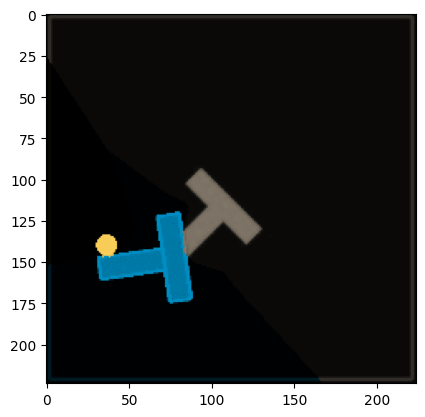

In [10]:
img_r=recolor_pusht(img, sigma=60) 
plt.imshow(img_r)

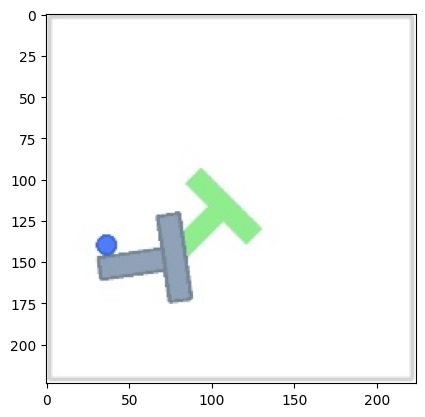

In [11]:
plt.imshow(img)

ep_starts[:5]: [0, 109, 218, 327, 436]
ds.lengths[:5]: [109, 109, 109, 109, 109]
ep   0 row      0  raw_mean_rgb=[247, 249, 248]  state[:3]=[423.0, 182.0, 192.67100524902344]
ep   1 row    109  raw_mean_rgb=[247, 249, 248]  state[:3]=[423.0, 182.0, 192.67100524902344]
ep   2 row    218  raw_mean_rgb=[247, 249, 248]  state[:3]=[423.0, 182.0, 192.67100524902344]
ep  10 row   1090  raw_mean_rgb=[247, 249, 248]  state[:3]=[423.0, 182.0, 192.67100524902344]
ep  50 row   5450  raw_mean_rgb=[247, 249, 248]  state[:3]=[423.0, 182.0, 192.67100524902344]

pairwise mean |ΔRGB|  (raw / recolored):
  ep   0 vs ep   1:    0.02  /    0.01
  ep   0 vs ep   2:    0.07  /    0.07
  ep   0 vs ep  10:    0.00  /    0.00
  ep   0 vs ep  50:    0.04  /    0.02
  ep   1 vs ep   2:    0.08  /    0.07
  ep   1 vs ep  10:    0.02  /    0.01
  ep   1 vs ep  50:    0.02  /    0.01
  ep   2 vs ep  10:    0.07  /    0.07
  ep   2 vs ep  50:    0.09  /    0.07
  ep  10 vs ep  50:    0.04  /    0.02


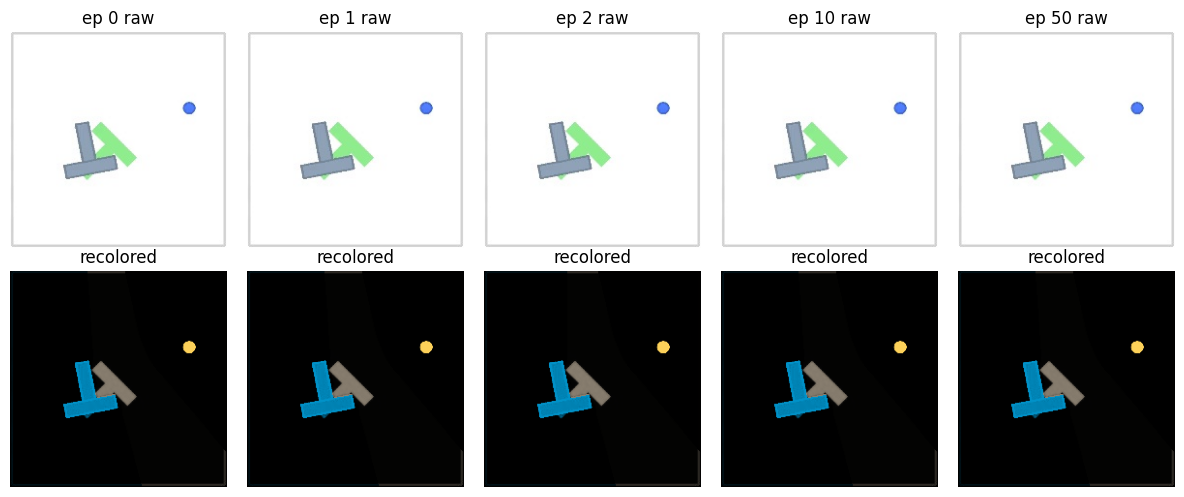

In [12]:
import itertools

print("ep_starts[:5]:", ep_starts[:5].tolist())
print("ds.lengths[:5]:", ds.lengths[:5].tolist())

# Pull the first frame of 5 different episodes, raw and recolored.
ep_ids = [0, 1, 2, 10, 50]
raw, rec = [], []
for ep_id in ep_ids:
    s = ds[int(ep_starts[ep_id])]
    img = to_hwc_uint8(s["pixels"])
    raw.append(img)
    rec.append(recolor_pusht(img, sigma=50))
    print(f"ep {ep_id:3d} row {int(ep_starts[ep_id]):6d}  "
          f"raw_mean_rgb={img.mean(axis=(0,1)).astype(int).tolist()}  "
          f"state[:3]={s['state'].squeeze(0).cpu().numpy()[:3].round(3).tolist()}")

print("\npairwise mean |ΔRGB|  (raw / recolored):")
for i, j in itertools.combinations(range(len(ep_ids)), 2):
    d_raw = np.abs(raw[i].astype(int) - raw[j].astype(int)).mean()
    d_rec = np.abs(rec[i].astype(int) - rec[j].astype(int)).mean()
    print(f"  ep {ep_ids[i]:3d} vs ep {ep_ids[j]:3d}:  {d_raw:6.2f}  /  {d_rec:6.2f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, len(ep_ids), figsize=(2.4*len(ep_ids), 5))
for k, (img, r) in enumerate(zip(raw, rec)):
    ax[0, k].imshow(img); ax[0, k].set_title(f"ep {ep_ids[k]} raw"); ax[0, k].axis("off")
    ax[1, k].imshow(r);   ax[1, k].set_title("recolored");          ax[1, k].axis("off")
plt.tight_layout(); plt.show()

In [13]:
np.random.seed(2)
rI=np.arange(len(ep_starts))
np.random.shuffle(rI)

In [14]:
rI

array([10738,  6613,  3369, ..., 11798,  6637,  2575], shape=(18686,))

In [15]:
for count in tqdm(range(N_EPISODES), desc="episodes"):
    ep_id=rI[count]
    
    ep_len = int(ds.lengths[ep_id])
    row0   = int(ep_starts[ep_id])

    ep_dir     = OUT_DIR / f"ep_{count:04d}"
    frames_dir = ep_dir / "frames"
    frames_dir.mkdir(parents=True, exist_ok=True)

    actions  = np.empty((ep_len, 2), dtype=np.float32)
    proprio  = np.empty((ep_len, 4), dtype=np.float32)
    state    = np.empty((ep_len, 7), dtype=np.float32)
    step_idx = np.empty((ep_len,),   dtype=np.int64)

    for t in range(ep_len):
        sample = ds[row0 + t]
        img    = to_hwc_uint8(sample["pixels"])
        img_r=recolor_pusht(img, sigma=50) 
        Image.fromarray(img_r).save(frames_dir / f"{t:04d}.png")

        actions[t]  = sample["action"].squeeze(0).cpu().numpy()
        proprio[t]  = sample["proprio"].squeeze(0).cpu().numpy()
        state[t]    = sample["state"].squeeze(0).cpu().numpy()
        step_idx[t] = int(sample["step_idx"].item())

    np.savez(
        ep_dir / "data.npz",
        action=actions,
        proprio=proprio,
        state=state,
        step_idx=step_idx,
        episode_idx=np.int64(ep_id),
        length=np.int64(ep_len),
    )

episodes: 100%|█| 100/100 [03:13<00:00,


In [63]:
ep_starts

array([      0,     109,     218, ..., 2336510, 2336623, 2336736],
      shape=(18686,))

---

In [29]:
DEFAULT_PALETTE: dict = {
    # ── source anchors (sampled from PushT renderer) ─────────────────────
    "src_bg":            np.array([255, 255, 255], dtype=np.float32),
    "src_frame_border":  np.array([205, 205, 205], dtype=np.float32),
    "src_target_fill":   np.array([130, 236, 138], dtype=np.float32),  # green T
    "src_movable_fill":  np.array([130, 153, 172], dtype=np.float32),  # blue-gray T
    "src_effector_fill": np.array([ 70, 119, 246], dtype=np.float32),  # blue dot
    "src_target_outline":   np.array([170, 212, 161], dtype=np.float32),  # green T
    "src_movable_outline":  np.array([125, 136, 143], dtype=np.float32),  # blue-gray T
    "src_effector_outline": np.array([94, 115, 167], dtype=np.float32),  # blue dot

    
    
    # ── target colors ────────────────────────────────────────────────────
    "tgt_bg":             BLACK,
    "tgt_target_fill":    CHILL_BROWN,
    "tgt_movable_fill":   BLUE,
    "tgt_effector_fill":  YELLOW,
    "tgt_target_outline":   CHILL_BROWN,
    "tgt_movable_outline":  BLUE,
    "tgt_effector_outline": YELLOW_FADE,

    # ── thresholds for labeling each shape's fill (color-ball radii) ─────
    # loose — only needs to find *some* fill pixels per shape; propagation does the rest
    "r_target_fill":   45.0,
    "r_movable_fill":  22.0,
    "r_effector_fill": 55.0,
}

In [30]:
def _label_shapes(img: np.ndarray, p: dict) -> np.ndarray:
    """Hard-label each pixel by nearest shape fill. 1=target, 2=movable, 3=effector."""
    def ball(anchor, r):
        return np.linalg.norm(img - anchor, axis=-1) < r

    labels = np.zeros(img.shape[:2], dtype=np.int32)
    labels[ball(p["src_target_fill"],   p["r_target_fill"])]   = 1
    labels[ball(p["src_movable_fill"],  p["r_movable_fill"])]  = 2
    labels[ball(p["src_effector_fill"], p["r_effector_fill"])] = 3   # last wins on overlap

    if (labels == 0).all():
        # Pathological: nothing got labeled. Return zeros; outline target will fall back to bg.
        return labels

    # Propagate labels into unlabeled regions by spatial nearest-fill
    _, idx = ndi.distance_transform_edt(labels == 0, return_indices=True)
    return labels[idx[0], idx[1]]


def _build_outline_target(label_map: np.ndarray, p: dict) -> np.ndarray:
    """Per-pixel outline target color, driven by which shape each pixel belongs to."""
    H, W = label_map.shape
    out = np.zeros((H, W, 3), dtype=np.float32)
    out[label_map == 1] = p["tgt_target_outline"]
    out[label_map == 2] = p["tgt_movable_outline"]
    out[label_map == 3] = p["tgt_effector_outline"]
    return out


def recolor_pusht(
    frame: np.ndarray,
    palette: dict | None = None,
    sigma: float = 18.0,
) -> np.ndarray:
    """Recolor one PushT frame.

    Args:
        frame:   (H, W, 3) uint8 RGB array.
        palette: dict matching DEFAULT_PALETTE structure (or None for defaults).
        sigma:   Gaussian σ in RGB units. Lower = crisper edges, higher = softer.
                 18 is a good default; 8–25 is the useful range.

    Returns:
        (H, W, 3) uint8 RGB array.
    """
    p = palette if palette is not None else DEFAULT_PALETTE
    img = frame.astype(np.float32)
    H, W, _ = img.shape

    # Stack source anchors — outline is LAST (per-pixel target)
    src = np.stack([
        p["src_bg"],
        p["src_frame_border"],
        p["src_target_fill"],
        p["src_movable_fill"],
        p["src_effector_fill"],
        p["src_outline"],
    ])  # (6, 3)

    # Constant target colors for anchors 0..4 (bg, frame, target, movable, effector)
    tgt_const = np.stack([
        p["tgt_bg"],
        p["tgt_bg"],            # frame border folds into background
        p["tgt_target_fill"],
        p["tgt_movable_fill"],
        p["tgt_effector_fill"],
    ])  # (5, 3)

    # Per-pixel outline target (anchor index 5)
    label_map     = _label_shapes(img, p)
    tgt_outline_pp = _build_outline_target(label_map, p)

    # Gaussian softmin weights
    flat = img.reshape(-1, 1, 3)                          # (N, 1, 3)
    d2   = ((flat - src[None]) ** 2).sum(-1)              # (N, 6)
    w    = np.exp(-d2 / (2.0 * sigma * sigma))
    w   /= w.sum(1, keepdims=True)                        # (N, 6)

    # Blend: 5 constant targets + 1 per-pixel target
    out  = w[:, :5] @ tgt_const                           # (N, 3)
    out += w[:, 5:6] * tgt_outline_pp.reshape(-1, 3)

    return np.clip(out, 0, 255).reshape(H, W, 3).astype(np.uint8)

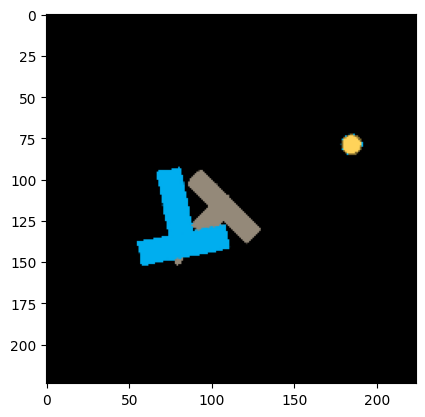

In [31]:
img_r=recolor_pusht(img, sigma=10) 
plt.imshow(img_r)

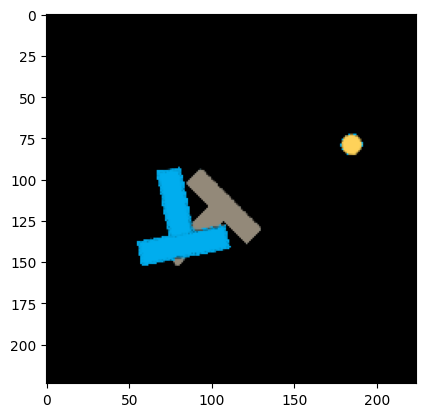

In [28]:
img_r=recolor_pusht(img, sigma=20) 
plt.imshow(img_r)

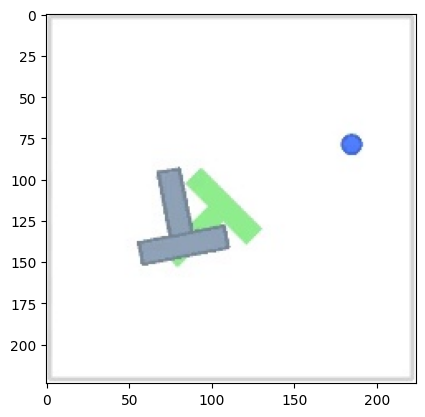

In [18]:
plt.imshow(img)

In [ ]:
    for t in range(ep_len):
        sample = ds[row0 + t]
        img    = to_hwc_uint8(sample["pixels"])
        Image.fromarray(img).save(frames_dir / f"{t:04d}.png")

        actions[t]  = sample["action"].squeeze(0).cpu().numpy()
        proprio[t]  = sample["proprio"].squeeze(0).cpu().numpy()
        state[t]    = sample["state"].squeeze(0).cpu().numpy()
        step_idx[t] = int(sample["step_idx"].item())